# 09 — Hybridation avec séparation des rôles

Au notebook 08, les hybrides A1 et A2 n'apportent aucun gain sur le ML pur (A1-XGBoost 4.51 dB contre 4.46 dB). Ce notebook teste une explication : **le ML reçoit les mêmes entrées que le modèle empirique**, donc rien ne l'oblige à laisser à Hata le soin de porter la tendance grande échelle. Il peut la réapprendre lui-même, et l'hybride s'effondre alors sur du ML pur.

## Le principe de l'hybridation
La division du travail voulue est : le modèle physique porte la dépendance en distance, fréquence et hauteur d'antenne ; le ML corrige ce que la formule ne sait pas représenter — relief, encombrement, météo. Si on redonne au ML les covariables de Hata, cette séparation n'est plus imposée.

## Covariables de Hata présentes dans l'espace des 22 features
Okumura-Hata prend en entrée `Freq`, `Distance`, la hauteur d'antenne d'émission, la hauteur d'antenne de réception et l'ERP, plus le commutateur urbain/suburbain. Leurs analogues dans le jeu de features sont :

| Entrée de Hata | Feature correspondante | Sort ? |
|---|---|---|
| d | `Distance` | oui |
| f | `Freq` | oui |
| ERP | `Tx_power` | oui |
| h_b | `Tx_height` (absolue, 109/167/427 m) | oui |
| urbain/suburbain | `Environment` | selon la variante |
| h_m | — | **non** : `Rx_antenna_height` = 10 m partout, donc `a_hm` est constante et Hata n'utilise aucune information de hauteur de réception variable. `Rx_height` (altitude absolue du récepteur) est une variable de **relief**, pas une entrée de Hata : elle reste. |

## Trois variantes comparées
- **Complète** — les 22 features (protocole du notebook 08, repris pour référence)
- **Réduite** — sans `Distance`, `Freq`, `Tx_power`, `Tx_height` (4 retirées, 18 restantes) ; `Environment` conservée car elle porte aussi de l'encombrement au-delà de son usage dans Hata
- **Stricte** — sans ces 4 plus `Environment` (5 retirées, 17 restantes)

Protocole identique au notebook 08 : ablation en validation croisée répétée **dans Dev**, Ê_L2 réajusté dans chaque pli, N\* par la règle du plateau à 1 erreur type, **une seule lecture du test** à la fin.


---
## §0 — Configuration et reprise des notebooks 07 / 08

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

BASE = Path('.').resolve()
NB07, NB08 = BASE / 'outputs_nb07', BASE / 'outputs_nb08'
OUT = BASE / 'outputs_nb09'; OUT.mkdir(exist_ok=True)

SEED, TARGET = 42, 'E_field'
np.random.seed(SEED)
ABL_SPLITS, ABL_REPEATS = 5, 2
ML_NAMES = ['RF', 'XGBoost', 'CatBoost', 'LightGBM']

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

def evaluate(y, p):
    return {'RMSE': float(np.sqrt(mean_squared_error(y, p))),
            'MAE': float(mean_absolute_error(y, p)),
            'R2': float(r2_score(y, p)), 'Bias': float(np.mean(p - y))}

with open(NB07 / 'best_params_dev.json') as f:
    BEST = json.load(f)

imp_multi = pd.read_csv(NB07 / 'feature_importance_multi_dev.csv', index_col=0)
TIE_BREAK_ORDER = ['First_building_m', 'Fresnel_trees']
BORDA_ORDER = []
for rank in sorted(imp_multi['Borda_rank'].unique()):
    g = imp_multi[imp_multi['Borda_rank'] == rank].index.tolist()
    if len(g) > 1:
        g = [f for f in TIE_BREAK_ORDER if f in g] + [f for f in g if f not in TIE_BREAK_ORDER]
    BORDA_ORDER.extend(g)

def build_ml(name):
    p = BEST[name].copy()
    if name == 'RF':       return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == 'XGBoost':  return XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, **p)
    if name == 'CatBoost': return CatBoostRegressor(random_seed=SEED, verbose=0, thread_count=-1, **p)
    if name == 'LightGBM': return lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, **p)

print('Ordre de Borda repris du nb 07 :', BORDA_ORDER[:6], '...')

Ordre de Borda repris du nb 07 : ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum', 'Freq'] ...


---
## §1 — Données, split, filtre d ≥ 1 km et calibration L2 (identiques au nb 08)

In [2]:
df = pd.read_csv(BASE / 'radio_features_clean_ref.csv')
dev_df, test_df = train_test_split(df, test_size=0.20, random_state=SEED,
                                   stratify=df['Environment'])
dev_df, test_df = dev_df.reset_index(drop=True), test_df.reset_index(drop=True)
dev_f  = dev_df[dev_df['Distance']  >= 1000.0].copy().reset_index(drop=True)
test_f = test_df[test_df['Distance'] >= 1000.0].copy().reset_index(drop=True)
y_dev_f, y_test_f = dev_f[TARGET].values, test_f[TARGET].values
env_test_f = test_f['Environment'].values

def build_ols_df(d):
    d_km = d['Distance'].values / 1000.0
    h_b, h_m = d['Tx_antenna_height'].values, d['Rx_antenna_height'].values
    return pd.DataFrame({
        'log_d': np.log10(d_km), 'log_f': np.log10(d['Freq'].values),
        'log_hb': np.log10(h_b), 'a_hm': 3.2*(np.log10(11.75*h_m))**2 - 4.97,
        'log_hb_log_d': np.log10(h_b)*np.log10(d_km),
        'log_erp': np.log10(d['Tx_power'].values),
        'Environment': d['Environment'].values.astype(float)})

ols_l2 = sm.OLS(y_dev_f, sm.add_constant(build_ols_df(dev_f))).fit()
e_l2_dev  = ols_l2.predict(sm.add_constant(build_ols_df(dev_f))).values
e_l2_test = ols_l2.predict(sm.add_constant(build_ols_df(test_f))).values
delta_l2_dev = y_dev_f - e_l2_dev

print(f'Dev filtré {len(dev_f)} | Test filtré {len(test_f)}')
print(f'Ê_L2 sur le test : RMSE = {np.sqrt(mean_squared_error(y_test_f, e_l2_test)):.3f} dB')

Dev filtré 242 | Test filtré 62
Ê_L2 sur le test : RMSE = 6.998 dB


---
## §2 — Définition des trois espaces de features

In [3]:
HATA_PROPAG = ['Distance', 'Freq', 'Tx_power', 'Tx_height']   # entrées directes de Hata
HATA_SWITCH = ['Environment']                                  # commutateur urbain/suburbain

VARIANTS = {
    'Full (19)': BORDA_ORDER,
    'Reduced (15)':  [f for f in BORDA_ORDER if f not in HATA_PROPAG],
    'Strict (14)':  [f for f in BORDA_ORDER if f not in HATA_PROPAG + HATA_SWITCH],
}
for k, v in VARIANTS.items():
    print(f'{k:16s} {len(v):2d} features')
    print(f'                 {v}')
    print()
print('Rappel : Rx_height est conservée dans toutes les variantes — Hata ne')
print("l'utilise pas (a_hm est constante puisque Rx_antenna_height = 10 m partout),")
print("c'est une variable de relief.")

Full (19)        19 features
                 ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum', 'Freq', 'Trees_near_Rx', 'Distance', 'Tx_height', 'Tilt_Tx_Rx', 'Tx_power', 'Temp', 'Buildings_near_Rx', 'Environment', 'LOS', 'First_tree_m', 'First_building_m', 'Fresnel_trees', 'Fresnel_buildings']

Reduced (15)     15 features
                 ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum', 'Trees_near_Rx', 'Tilt_Tx_Rx', 'Temp', 'Buildings_near_Rx', 'Environment', 'LOS', 'First_tree_m', 'First_building_m', 'Fresnel_trees', 'Fresnel_buildings']

Strict (14)      14 features
                 ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum', 'Trees_near_Rx', 'Tilt_Tx_Rx', 'Temp', 'Buildings_near_Rx', 'LOS', 'First_tree_m', 'First_building_m', 'Fresnel_trees', 'Fresnel_buildings']

Rappel : Rx_height est conservée dans toutes les variantes — Hata ne
l'utilise pas (a_hm est constante puisque Rx_antenna

---
## §3 — Ablation des variantes réduites, en validation croisée dans Dev

Ê_L2 est réajusté par OLS dans chaque pli d'entraînement, comme au notebook 08.

In [4]:
rkf = RepeatedKFold(n_splits=ABL_SPLITS, n_repeats=ABL_REPEATS, random_state=SEED)
folds = list(rkf.split(dev_f))
n_est = len(folds)

# Ê_L2 par pli — calculé une seule fois, réutilisé pour toutes les variantes
fold_l2 = []
for tr, va in folds:
    d_tr, d_va = dev_f.iloc[tr], dev_f.iloc[va]
    o = sm.OLS(d_tr[TARGET].values, sm.add_constant(build_ols_df(d_tr))).fit()
    fold_l2.append((tr, va,
                    o.predict(sm.add_constant(build_ols_df(d_tr))).values,
                    o.predict(sm.add_constant(build_ols_df(d_va))).values))

def ablation(order, approach):
    '''RMSE de validation dans Dev pour N = 1..len(order).'''
    rows = []
    for n in range(1, len(order) + 1):
        feats = order[:n]
        row = {'N': n}
        acc = {m: [] for m in ML_NAMES}
        for tr, va, e_tr, e_va in fold_l2:
            d_tr, d_va = dev_f.iloc[tr], dev_f.iloc[va]
            ytr, yva = d_tr[TARGET].values, d_va[TARGET].values
            if approach == 'A1':
                Xtr = np.column_stack([d_tr[feats].values, e_tr])
                Xva = np.column_stack([d_va[feats].values, e_va])
                for mdl in ML_NAMES:
                    m = build_ml(mdl); m.fit(Xtr, ytr)
                    acc[mdl].append(float(np.sqrt(mean_squared_error(yva, m.predict(Xva)))))
            else:
                Xtr, Xva = d_tr[feats].values, d_va[feats].values
                for mdl in ML_NAMES:
                    m = build_ml(mdl); m.fit(Xtr, ytr - e_tr)
                    acc[mdl].append(float(np.sqrt(mean_squared_error(yva, e_va + m.predict(Xva)))))
        for mdl in ML_NAMES:
            row[f'{mdl}_RMSE']   = round(float(np.mean(acc[mdl])), 4)
            row[f'{mdl}_RMSEsd'] = round(float(np.std(acc[mdl], ddof=1)), 4)
        rows.append(row)
    return pd.DataFrame(rows)

ABL = {}
for vname in ['Reduced (15)', 'Strict (14)']:
    for approach in ['A1', 'A2']:
        key = f'{approach} · {vname}'
        print(f'--- {key} ---')
        ABL[key] = ablation(VARIANTS[vname], approach)
        best = {m: ABL[key][f'{m}_RMSE'].min() for m in ML_NAMES}
        print('   meilleur RMSE Dev : ' + '  '.join(f'{m}={v:.3f}' for m, v in best.items()))

# variantes complètes : déjà calculées au notebook 08
ABL['A1 · Full (19)'] = pd.read_csv(NB08 / 'hybrid_A1_ablation_dev.csv')
ABL['A2 · Full (19)'] = pd.read_csv(NB08 / 'hybrid_A2_ablation_dev.csv')
for k, v in ABL.items():
    v.to_csv(OUT / f'ablation_{k.replace(" · ", "_").replace(" ", "").replace("(", "").replace(")", "")}.csv', index=False)
print('\nAblations sauvées → outputs_nb09/')

--- A1 · Reduced (15) ---


   meilleur RMSE Dev : RF=5.479  XGBoost=5.637  CatBoost=5.558  LightGBM=5.465
--- A2 · Reduced (15) ---


   meilleur RMSE Dev : RF=5.539  XGBoost=5.584  CatBoost=5.556  LightGBM=5.639
--- A1 · Strict (14) ---


   meilleur RMSE Dev : RF=5.479  XGBoost=5.628  CatBoost=5.532  LightGBM=5.465
--- A2 · Strict (14) ---


   meilleur RMSE Dev : RF=5.539  XGBoost=5.580  CatBoost=5.557  LightGBM=5.658

Ablations sauvées → outputs_nb09/


In [5]:
# ── N* par la règle du plateau à 1 erreur type ───────────────────────────────
def pick_nstar(abl, mdl):
    mu, sd = abl[f'{mdl}_RMSE'].values, abl[f'{mdl}_RMSEsd'].values
    j = int(np.argmin(mu))
    thr = mu[j] + sd[j] / np.sqrt(n_est)
    return int(abl['N'].values[np.argmax(mu <= thr)])

NSTAR = {}
rows = []
for key, abl in ABL.items():
    approach, vname = key.split(' · ')
    for mdl in ML_NAMES:
        n = pick_nstar(abl, mdl)
        NSTAR[(approach, vname, mdl)] = n
        rows.append({'Approche': approach, 'Variante': vname, 'Model': mdl,
                     'N*': n, 'RMSE_dev': abl[f'{mdl}_RMSE'].values[n-1]})
nstar_df = pd.DataFrame(rows)
nstar_df.to_csv(OUT / 'nstar_variantes.csv', index=False)

piv = nstar_df.pivot_table(index=['Approche', 'Model'], columns='Variante',
                           values='RMSE_dev').round(3)
print('=== RMSE de validation dans Dev au N* retenu ===')
print(piv.to_string())

=== RMSE de validation dans Dev au N* retenu ===
Variante           Full (19)  Reduced (15)  Strict (14)
Approche Model                                         
A1       CatBoost      5.584         5.584        5.584
         LightGBM      5.484         5.465        5.465
         RF            5.548         5.548        5.548
         XGBoost       5.748         5.748        5.748
A2       CatBoost      5.558         5.558        5.558
         LightGBM      5.680         5.734        5.734
         RF            5.623         5.623        5.623
         XGBoost       5.698         5.698        5.698


---
## §4 — Évaluation finale sur le test scellé

In [6]:
rows = []
preds = {}
for key, abl in ABL.items():
    approach, vname = key.split(' · ')
    order = VARIANTS[vname]
    for mdl in ML_NAMES:
        n = NSTAR[(approach, vname, mdl)]
        feats = order[:n]
        if approach == 'A1':
            m = build_ml(mdl)
            m.fit(np.column_stack([dev_f[feats].values, e_l2_dev]), y_dev_f)
            p = m.predict(np.column_stack([test_f[feats].values, e_l2_test]))
        else:
            m = build_ml(mdl); m.fit(dev_f[feats].values, delta_l2_dev)
            p = e_l2_test + m.predict(test_f[feats].values)
        preds[(approach, vname, mdl)] = p
        rows.append({'Approche': approach, 'Variante': vname, 'Modèle': mdl,
                     'N*': n, **evaluate(y_test_f, p)})

res = pd.DataFrame(rows)
for c in ['RMSE', 'MAE', 'Bias']: res[c] = res[c].round(3)
res['R2'] = res['R2'].round(3)
res.to_csv(OUT / 'resultats_test_variantes.csv', index=False)

print(f'=== Test scellé (d≥1 km, n={len(test_f)}) — hybrides selon l espace de features ===')
print(res.to_string(index=False))
print()
pv = res.pivot_table(index=['Approche', 'Modèle'], columns='Variante', values='RMSE')
pv = pv[['Full (19)', 'Reduced (15)', 'Strict (14)']]
pv['Δ Réduite'] = (pv['Reduced (15)'] - pv['Full (19)']).round(3)
pv['Δ Stricte'] = (pv['Strict (14)'] - pv['Full (19)']).round(3)
print('=== RMSE sur le test, par variante (Δ négatif = le retrait aide) ===')
print(pv.round(3).to_string())

=== Test scellé (d≥1 km, n=62) — hybrides selon l espace de features ===
Approche     Variante   Modèle  N*  RMSE   MAE    R2   Bias
      A1 Reduced (15)       RF   3 5.190 4.267 0.728  0.299
      A1 Reduced (15)  XGBoost   4 5.002 4.032 0.747  0.172
      A1 Reduced (15) CatBoost   3 5.277 4.268 0.719  0.392
      A1 Reduced (15) LightGBM   9 4.815 4.051 0.766  0.241
      A2 Reduced (15)       RF   3 5.233 4.343 0.724  0.188
      A2 Reduced (15)  XGBoost   5 5.054 4.048 0.742  0.556
      A2 Reduced (15) CatBoost   5 4.738 3.993 0.773  0.481
      A2 Reduced (15) LightGBM   5 4.963 4.076 0.751  0.400
      A1  Strict (14)       RF   3 5.190 4.267 0.728  0.299
      A1  Strict (14)  XGBoost   4 5.002 4.032 0.747  0.172
      A1  Strict (14) CatBoost   3 5.277 4.268 0.719  0.392
      A1  Strict (14) LightGBM   9 4.815 4.051 0.766  0.241
      A2  Strict (14)       RF   3 5.233 4.343 0.724  0.188
      A2  Strict (14)  XGBoost   5 5.054 4.048 0.742  0.556
      A2  Strict (14) CatBo

In [7]:
# ── Référence : ML pur, et bilan ────────────────────────────────────────────
cf = pd.read_csv(NB08 / 'cross_family_final.csv')
pure = cf[cf['Famille'] == 'Pure ML'][['Modèle', 'N', 'RMSE', 'R2']]
best_pure = pure.sort_values('RMSE').iloc[0]
l2_rmse = float(cf[cf['Modèle'] == 'Hata L2 (OLS)']['RMSE'].iloc[0])

print('Références (notebook 08) :')
print(f'  Hata L2 seul          : RMSE = {l2_rmse:.3f} dB')
print(f'  Meilleur ML pur       : {best_pure["Modèle"]} (N={best_pure["N"]}) '
      f'RMSE = {best_pure["RMSE"]:.3f} dB   R² = {best_pure["R2"]:.3f}')
print()
for v in ['Full (19)', 'Reduced (15)', 'Strict (14)']:
    b = res[res['Variante'] == v].sort_values('RMSE').iloc[0]
    print(f'  Meilleur hybride {v:14s} : {b["Approche"]}-{b["Modèle"]} (N*={b["N*"]}) '
          f'RMSE = {b["RMSE"]:.3f} dB   R² = {b["R2"]:.3f}   '
          f'vs ML pur : {b["RMSE"] - best_pure["RMSE"]:+.3f} dB')

Références (notebook 08) :
  Hata L2 seul          : RMSE = 6.998 dB
  Meilleur ML pur       : RF (N=5) RMSE = 4.776 dB   R² = 0.770

  Meilleur hybride Full (19)      : A2-CatBoost (N*=5) RMSE = 4.738 dB   R² = 0.773   vs ML pur : -0.038 dB
  Meilleur hybride Reduced (15)   : A2-CatBoost (N*=5) RMSE = 4.738 dB   R² = 0.773   vs ML pur : -0.038 dB
  Meilleur hybride Strict (14)    : A2-CatBoost (N*=5) RMSE = 4.738 dB   R² = 0.773   vs ML pur : -0.038 dB


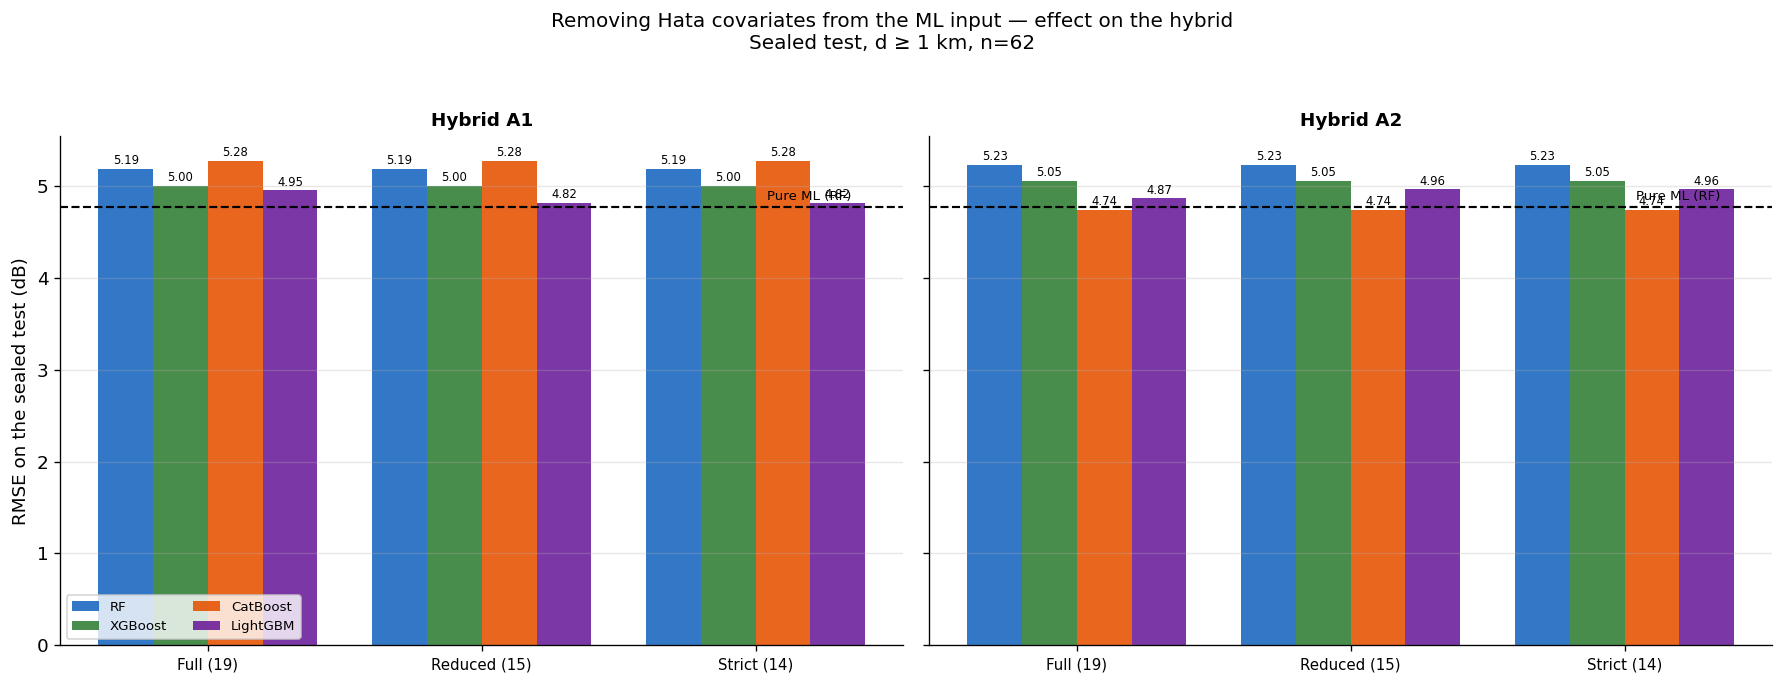

In [8]:
# ── Figure : effet du retrait des covariables de Hata ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
VAR_ORDER = ['Full (19)', 'Reduced (15)', 'Strict (14)']
COLS = {'RF': '#1565C0', 'XGBoost': '#2E7D32', 'CatBoost': '#E65100', 'LightGBM': '#6A1B9A'}
x = np.arange(len(VAR_ORDER)); w = 0.2

for ax, approach in zip(axes, ['A1', 'A2']):
    for i, (mdl, c) in enumerate(COLS.items()):
        vals = [res[(res.Approche == approach) & (res.Variante == v) & (res['Modèle'] == mdl)]['RMSE'].iloc[0]
                for v in VAR_ORDER]
        b = ax.bar(x + (i - 1.5) * w, vals, w, color=c, alpha=0.88, label=mdl)
        ax.bar_label(b, fmt='%.2f', fontsize=7, padding=1)
    ax.axhline(best_pure['RMSE'], color='black', ls='--', lw=1.3)
    ax.text(2.35, best_pure['RMSE'] + 0.04, f"Pure ML ({best_pure['Modèle']})",
            fontsize=8, ha='right', va='bottom')
    ax.set_xticks(x); ax.set_xticklabels(VAR_ORDER, fontsize=9)
    ax.set_title(f'Hybrid {approach}', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('RMSE on the sealed test (dB)')
axes[0].legend(fontsize=8, ncol=2)
plt.suptitle("Removing Hata covariates from the ML input — effect on the hybrid\n"
             f"Sealed test, d ≥ 1 km, n={len(test_f)}", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(OUT / 'fig_variantes_hybrides.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_variantes_hybrides.png', dpi=150, bbox_inches='tight')
plt.show()

---
## §5 — Tableau pour le manuscrit

Version sans la ventilation par ville, comme demandé : métriques globales uniquement, sur le test scellé filtré à d ≥ 1 km.

In [9]:
best_hyb_all = res.sort_values('RMSE').iloc[0]
rows_ms = [
    ('Uncalibrated empirical', 'ITU-R P.1546-6', '—'),
    ('Uncalibrated empirical', 'Hata standard', '—'),
    ('Calibrated empirical', 'Hata L1a (global offset)', '1'),
    ('Calibrated empirical', 'Hata L1b (offset/env)', '2'),
    ('Calibrated empirical', 'Hata L2 (OLS)', '7'),
]
ms = []
for fam, mod, n in rows_ms:
    r = cf[cf['Modèle'] == mod].iloc[0]
    ms.append({'Family': fam, 'Model': mod, 'N': n, 'RMSE (dB)': r['RMSE'],
               'MAE (dB)': r['MAE'], 'R2': r['R2'], 'Bias (dB)': r['Bias']})
for _, r in cf[cf['Famille'] == 'Pure ML'].sort_values('RMSE').iterrows():
    ms.append({'Family': 'Pure ML', 'Model': r['Modèle'], 'N': str(r['N']),
               'RMSE (dB)': r['RMSE'], 'MAE (dB)': r['MAE'], 'R2': r['R2'], 'Bias (dB)': r['Bias']})
b = best_hyb_all
ms.append({'Family': f'Hybride ({b["Variante"]})', 'Model': f'{b["Approche"]}-{b["Modèle"]}',
           'N': str(int(b['N*'])), 'RMSE (dB)': b['RMSE'], 'MAE (dB)': b['MAE'],
           'R2': b['R2'], 'Bias (dB)': b['Bias']})

ms_df = pd.DataFrame(ms)
for c in ['RMSE (dB)', 'MAE (dB)', 'Bias (dB)']: ms_df[c] = ms_df[c].round(2)
ms_df['R2'] = ms_df['R2'].round(3)
ms_df.to_csv(OUT / 'tableau_manuscrit.csv', index=False)

cols = ms_df.columns.tolist()
wds = [max(len(c), ms_df[c].astype(str).map(len).max()) for c in cols]
print('| ' + ' | '.join(c.ljust(w) for c, w in zip(cols, wds)) + ' |')
print('|' + '|'.join('-'*(w+2) for w in wds) + '|')
for _, r in ms_df.iterrows():
    print('| ' + ' | '.join(str(v).ljust(w) for v, w in zip(r.tolist(), wds)) + ' |')
print(f'\n[test scellé, d ≥ 1 km, n = {len(test_f)}]')
print('Sauvé → outputs_nb09/tableau_manuscrit.csv')

| Family                 | Model                    | N | RMSE (dB) | MAE (dB) | R2     | Bias (dB) |
|------------------------|--------------------------|---|-----------|----------|--------|-----------|
| Uncalibrated empirical | ITU-R P.1546-6           | — | 13.64     | 11.73    | -0.877 | -8.87     |
| Uncalibrated empirical | Hata standard            | — | 17.81     | 13.76    | -2.201 | 13.54     |
| Calibrated empirical   | Hata L1a (global offset) | 1 | 11.57     | 9.73     | -0.351 | 0.16      |
| Calibrated empirical   | Hata L1b (offset/env)    | 2 | 9.93      | 7.8      | 0.005  | -0.02     |
| Calibrated empirical   | Hata L2 (OLS)            | 7 | 7.0       | 5.37     | 0.506  | -0.1      |
| Pure ML                | RF                       | 5 | 4.78      | 4.02     | 0.77   | 0.42      |
| Pure ML                | CatBoost                 | 5 | 4.83      | 4.02     | 0.765  | 0.58      |
| Pure ML                | LightGBM                 | 5 | 4.88      | 4.03     | 0